##Seed Dataset with SOM

###Pochodzenie i cel powstania

**Pochodzenie:** Dane pochodzą z badań przeprowadzonych w Instytucie Agrofizyki Polskiej Akademii Nauk w Lublinie. Ziarna pszenicy (odmiany Kama, Rosa, Canadian) zostały zebrane z pól doświadczalnych i poddane analizie za pomocą techniki miękkiego promieniowania rentgenowskiego (soft X-ray).


**Cel powstania:** Celem było zbadanie i rozróżnienie odmian pszenicy na podstawie właściwości geometrycznych ziaren, mierzonych metodą rentgenowską.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [19]:
# @title
df = pd.read_csv('seeds_dataset.txt', delim_whitespace=True, header=None)
column_names = [
    'area',
    'perimeter',
    'compactness',
    'length_of_kernel',
    'width_of_kernel',
    'asymmetry_coefficient',
    'length_of_kernel_groove',
    'class'
]

df.columns = column_names

df

/tmp/ipython-input-1147061094.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('seeds_dataset.txt', delim_whitespace=True, header=None)


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


**Liczba próbek**: 210

**Atrybuty**:
*   Area - powierzchnia ziarna
*   Permiter - obwód
*   Compactness - miara „zwartości” kształtu.
*   length_of_kenrnel - długość ziarna
*   width_of_kernel - szerokość szerokość
*   assymetry_coefficient - wsp. asymetrii
*   length_of_kenrnel_groove - długość bruzdy
*   class -
    *   1 -> Kama
    *   2 -> Rosa
    *   3 -> Canadian



###**Stopień zbalansowania**

In [20]:
df['class'] = df['class'].map({
    1: 'Kama',
    2: 'Rosa',
    3: 'Canadian'
})
print(df["class"].value_counts())
print(df["class"].value_counts(normalize=True))

class
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64
class
Kama        0.333333
Rosa        0.333333
Canadian    0.333333
Name: proportion, dtype: float64


Zbiór jest idealnie zabalansowany, ponieważ każdy rodzaj pszenicy ma idealnie po 70 próbek.

Brak dysproporcji, dominacji żadnej klasy, więc SOM nie będzie faworyzował.

-------------------------------------



###**Potencjalne trudności**

cechy dotyczące kształtu mogą mieć różne skale, dlatego konieczna jest normalizacja

In [21]:
df.describe()

,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


Assymetry_coefficient ma amplitude ~7.7, dużo większą niż pozostałe parametry, więc należy go znormalizować.

Compactness posiada za to wyjątkowo niską wariancję.

###**Implementacja SOM**

In [23]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=96d3bed00a54d720f1afb45f2336a6598b91c6284282cbd76492712f42dde154
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom


In [24]:
# Oddzielenie cech od etykiet
X = df.drop(columns=['class']).values
y = df['class'].values

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
import numpy as np
N = X.shape[0]
map_size = int(5 * np.sqrt(N))  # ok. 72 neuronów
side = int(np.sqrt(map_size))   # ~8–9

som_x = side
som_y = side

print("SOM size:", som_x, "x", som_y)

SOM size: 8 x 8


In [29]:
from minisom import MiniSom

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)

som.train_random(X_scaled, num_iteration=500)

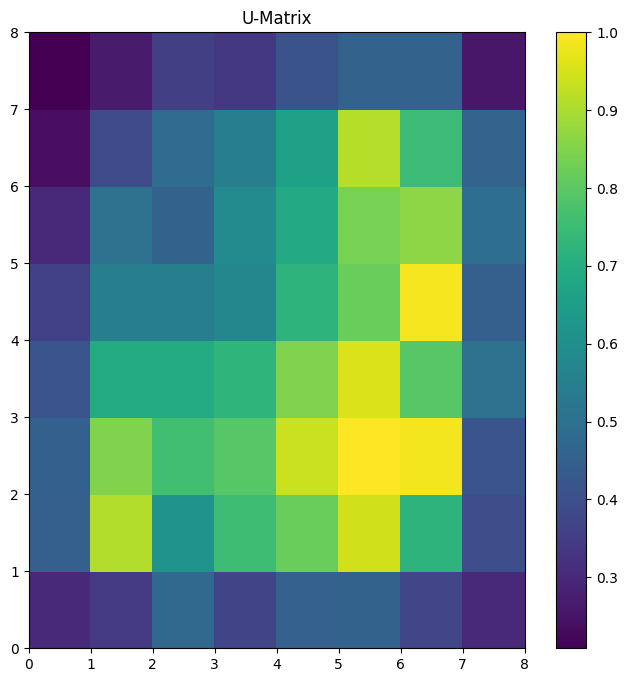

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.title("U-Matrix")
plt.pcolor(som.distance_map().T)
plt.colorbar()
plt.show()

###**Metryki SOM**

In [39]:

som = MiniSom(x=8, y=8, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.train_random(X_scaled, 500)

# Błąd kwantyzacji (QE)
qe = som.quantization_error(X_scaled)
print("Quantization Error (QE):", qe)

# Błąd topologiczny (TE)
te = som.topographic_error(X_scaled)
print("Topographic Error (TE):", te)


Quantization Error (QE): 0.566521993960836
Topographic Error (TE): 0.2761904761904762
